# Feature engineering

**CST4275 Master's Individual Thesis — Swetank Mohanty (M01087647)**
Supervisor: Dr Siddhaling Urolagin, Middlesex University Dubai

Turns `movies_merged` into the representations the three recommender modules consume:

| Representation | Feeds | Objective |
|---|---|---|
| TF-IDF over `overview_text` | plot-description module | 3 |
| Count vectors over `metadata_soup` | metadata module | 4 |
| Scaled numeric block + multi-hot genres | demographic module, feature ablations | 2, 5 |
| Sentence-transformer embeddings | deep-learning comparison | 5 |

**On similarity.** A dense 89,178 × 89,178 cosine matrix is 31.8 GB in float32 and cannot be
materialised. Two complementary strategies are built instead: the fitted vectorisers and sparse
matrices are persisted so any film can be scored against the whole catalogue on demand, and a
top-N neighbour table is precomputed for inspection and offline evaluation.

Everything is written to `datasets/processed/`.

## 0. Setup

In [1]:
from __future__ import annotations

import json
import re
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import polars as pl
import scipy.sparse as sp
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.utils.extmath import safe_sparse_dot

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "figure.autolayout": True,
    "axes.titlesize": 12, "axes.titleweight": "semibold",
    "axes.labelsize": 10, "axes.edgecolor": "#666666", "font.size": 10,
})
INK, ACCENT, MUTED = "#1F3864", "#4472C4", "#A6A6A6"
POS, NEG = "#2E7D5B", "#B4462F"
SEQ = "mako"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"python {sys.version.split()[0]} | polars {pl.__version__} | "
      f"numpy {np.__version__} | scipy {sp.__version__ if hasattr(sp, '__version__') else ''}")

python 3.11.15 | polars 1.43.1 | numpy 2.4.4 | scipy 


In [2]:
def find_project_root(marker: str = "datasets") -> Path:
    """Walk upwards until the folder containing `datasets` is found."""
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(f"no ancestor of {here} contains a {marker!r} directory")


ROOT = find_project_root()
PROC = ROOT / "datasets" / "processed"
FIGS = ROOT / "outputs" / "figures"
ARTIFACTS = PROC / "features"
for d in (FIGS, ARTIFACTS):
    d.mkdir(parents=True, exist_ok=True)

LIST_COLUMNS = (
    "genres", "keywords", "cast_top", "directors",
    "production_companies", "production_countries", "spoken_languages", "ml_tags",
)


def load_table(stem: str, *, base: Path = None, separator: str = "|", lazy: bool = False):
    """Load a build artifact, preferring Parquet and falling back to CSV.

    The pipeline defaults to CSV, which cannot store nested columns, so the list
    columns arrive as `separator`-delimited strings and are re-split here.
    """
    base = base or PROC
    parquet, csv = base / f"{stem}.parquet", base / f"{stem}.csv"
    if parquet.exists():
        frame = pl.scan_parquet(parquet) if lazy else pl.read_parquet(parquet)
        source = "parquet"
    elif csv.exists():
        frame = pl.scan_csv(csv, infer_schema_length=10_000) if lazy \
            else pl.read_csv(csv, infer_schema_length=10_000)
        present = [c for c in LIST_COLUMNS if c in frame.collect_schema().names()]
        if present:
            frame = frame.with_columns([
                pl.when(pl.col(c).is_null() | (pl.col(c) == ""))
                  .then(pl.lit([], dtype=pl.List(pl.String)))
                  .otherwise(pl.col(c).str.split(separator)).alias(c)
                for c in present
            ])
        source = "csv (list columns re-split)"
    else:
        raise FileNotFoundError(f"neither {parquet.name} nor {csv.name} in {base}")
    print(f"loaded {stem} from {source}")
    return frame


def save_fig(fig, name: str) -> None:
    path = FIGS / f"{name}.png"
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    print(f"  saved {path.relative_to(ROOT)}")


def sparsity_report(matrix, label: str) -> dict:
    """Summarise a sparse design matrix."""
    rows, cols = matrix.shape
    info = {
        "representation": label,
        "rows": rows,
        "features": cols,
        "stored values": matrix.nnz,
        "density": matrix.nnz / (rows * cols),
        "mean nnz/row": matrix.nnz / rows,
        "memory MB": (matrix.data.nbytes + matrix.indices.nbytes
                      + matrix.indptr.nbytes) / 1024**2,
    }
    return info

## 1. Load and define working subsets

In [3]:
items = load_table("movies_merged")
print(f"catalogue: {items.height:,} films x {items.width} columns")

# Each representation covers a different population. Carrying an explicit row->movie_id
# map per representation avoids the classic bug of indexing one matrix with another's
# positions once films without a given feature are dropped.
subsets = {
    "overview": items.filter(pl.col("has_overview")),
    "soup": items.filter(pl.col("metadata_soup").fill_null("").str.strip_chars() != ""),
    "structured": items,
}
display(pd.DataFrame([
    {"representation": k, "films": v.height, "share": v.height / items.height}
    for k, v in subsets.items()
]))

loaded movies_merged from parquet
catalogue: 89,178 films x 52 columns


,representation,films,share
0,overview,87556,0.981812
1,soup,88313,0.990300
2,structured,89178,1.000000


## 2. Text normalisation

`metadata_soup` is already lowercased and whitespace-stripped by the build pipeline, so it needs
no further work. Overviews are raw prose and do need cleaning. The cleaning is deliberately light:
aggressive stemming hurts more than it helps on short synopses, and the vectoriser handles
stopwords and case.

In [4]:
_URL = re.compile(r"https?://\S+|www\.\S+")
_NONWORD = re.compile(r"[^a-z0-9\s']")
_SPACE = re.compile(r"\s+")


def clean_overview(series: pl.Series) -> pl.Series:
    """Lowercase, strip URLs and punctuation, collapse whitespace."""
    return (series.fill_null("")
            .str.to_lowercase()
            .str.replace_all(_URL.pattern, " ")
            .str.replace_all(_NONWORD.pattern, " ")
            .str.replace_all(_SPACE.pattern, " ")
            .str.strip_chars())


overview_df = subsets["overview"].with_columns(
    clean_overview(pl.col("overview_text")).alias("overview_clean")
)
sample = overview_df.select("title_clean", "overview_text", "overview_clean").head(2).to_dicts()
for row in sample:
    print(f"\n{row['title_clean']}")
    print(f"  raw   : {row['overview_text'][:110]}")
    print(f"  clean : {row['overview_clean'][:110]}")

# A handful of overviews are boilerplate rather than plot. They carry no signal and would
# otherwise form a dense cluster of mutually similar films.
placeholders = overview_df.filter(
    pl.col("overview_clean").str.len_chars() < 20
).height
print(f"\noverviews shorter than 20 characters after cleaning: {placeholders:,}")


Toy Story
  raw   : Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene.
  clean : led by woody andy's toys live happily in his room until andy's birthday brings buzz lightyear onto the scene a

Jumanji
  raw   : When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unw
  clean : when siblings judy and peter discover an enchanted board game that opens the door to a magical world they unwi

overviews shorter than 20 characters after cleaning: 223


## 3. TF-IDF over overviews — the plot-description module

`min_df` is the parameter that matters most here. The EDA showed heavy-tailed vocabularies where
a large share of terms appear on a single film; those terms inflate dimensionality without
contributing similarity signal.

,min_df,vocabulary,stored values,mean nnz/row,fit seconds
0,1,1772866,4605632,52.602129,15.5
1,2,266188,3098954,35.393965,8.7
2,3,131147,2828872,32.309288,8.7
3,5,65871,2611826,29.830349,9.0
4,10,31126,2390785,27.305781,8.5


  saved outputs/figures/fe_tfidf_mindf_sweep.png


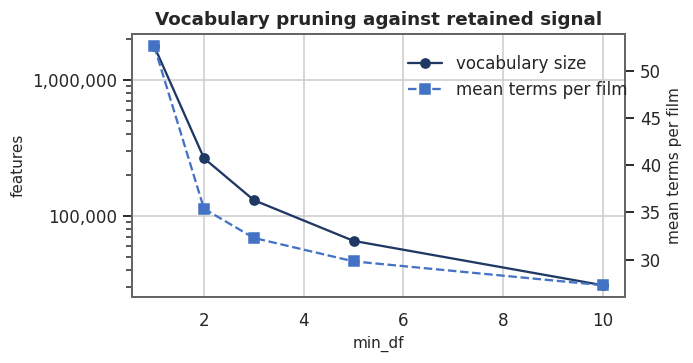

In [5]:
docs = overview_df["overview_clean"].to_list()

sweep = []
for min_df in (1, 2, 3, 5, 10):
    v = TfidfVectorizer(stop_words="english", min_df=min_df, max_df=0.5,
                        ngram_range=(1, 2), sublinear_tf=True, dtype=np.float32)
    t = time.time()
    m = v.fit_transform(docs)
    sweep.append({"min_df": min_df, "vocabulary": m.shape[1], "stored values": m.nnz,
                  "mean nnz/row": m.nnz / m.shape[0], "fit seconds": round(time.time() - t, 1)})
sweep_df = pd.DataFrame(sweep)
display(sweep_df)

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.plot(sweep_df["min_df"], sweep_df["vocabulary"], "o-", color=INK, label="vocabulary size")
ax.set_xlabel("min_df"); ax.set_ylabel("features"); ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax2 = ax.twinx()
ax2.plot(sweep_df["min_df"], sweep_df["mean nnz/row"], "s--", color=ACCENT,
         label="mean terms per film")
ax2.set_ylabel("mean terms per film"); ax2.grid(False)
ax.set_title("Vocabulary pruning against retained signal")
fig.legend(frameon=False, loc="upper right", bbox_to_anchor=(0.92, 0.88))
save_fig(fig, "fe_tfidf_mindf_sweep")
plt.show()

In [6]:
# min_df=3 keeps roughly a fifth of the unpruned vocabulary while losing only a few
# terms per film. Bigrams are retained: "serial killer" and "world war" carry meaning
# their unigrams do not.
TFIDF_PARAMS = dict(
    stop_words="english", min_df=3, max_df=0.5, ngram_range=(1, 2),
    sublinear_tf=True, max_features=120_000, norm="l2", dtype=np.float32,
)
tfidf = TfidfVectorizer(**TFIDF_PARAMS)
X_overview = tfidf.fit_transform(docs).astype(np.float32)
overview_ids = overview_df["movie_id"].to_numpy()

info_tfidf = sparsity_report(X_overview, "TF-IDF overview")
display(pd.Series(info_tfidf).to_frame("value"))

weights = np.asarray(X_overview.sum(axis=0)).ravel()
vocab = np.array(tfidf.get_feature_names_out())
top = pd.DataFrame({"term": vocab[np.argsort(-weights)][:25],
                    "total tf-idf weight": np.sort(weights)[::-1][:25]})
print("\nhighest-weight terms:")
display(top.head(12).T)

,value
representation,TF-IDF overview
rows,87556
features,120000
stored values,2795431
density,0.000266
mean nnz/row,31.927349
memory MB,21.661449



highest-weight terms:


,0,1,2,3,4,5,6,7,8,9,10,11
term,life,young,man,new,love,film,family,world,story,woman,old,time
total tf-idf weight,922.48877,866.750183,762.108276,695.896851,687.618652,687.359985,671.116516,658.401855,654.133118,602.586853,558.459229,506.825134


## 4. Count vectors over `metadata_soup` — the metadata module

representation,TF-IDF overview,Count metadata_soup
rows,8.755600e+04,88313.000000
features,1.200000e+05,48870.000000
stored values,2.795431e+06,754637.000000
density,2.660612e-04,0.000175
mean nnz/row,3.192735e+01,8.545027
memory MB,2.166145e+01,6.094315


  saved outputs/figures/fe_soup_vocabulary.png


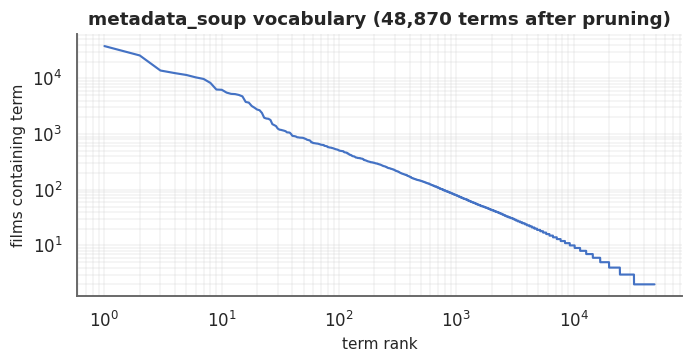

In [7]:
soup_df = subsets["soup"]
soup_docs = soup_df["metadata_soup"].to_list()

# The soup is pre-tokenised by the build pipeline: entities are lowercased with internal
# whitespace removed, so "Tom Hanks" is the single token "tomhanks". Splitting on
# whitespace alone preserves that; the default token pattern would keep it intact too but
# would also silently drop single-character tokens.
COUNT_PARAMS = dict(
    analyzer="word", token_pattern=r"\S+", min_df=2, max_df=0.6,
    max_features=200_000, dtype=np.int32,
)
counter = CountVectorizer(**COUNT_PARAMS)
X_soup_raw = counter.fit_transform(soup_docs)

# L2-normalise so cosine similarity is a plain dot product and long soups do not dominate.
from sklearn.preprocessing import normalize as l2_normalize
X_soup = l2_normalize(X_soup_raw.astype(np.float32))
soup_ids = soup_df["movie_id"].to_numpy()

info_soup = sparsity_report(X_soup, "Count metadata_soup")
display(pd.DataFrame([info_tfidf, info_soup]).set_index("representation").T)

doc_freq = np.asarray((X_soup_raw > 0).sum(axis=0)).ravel()
fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.loglog(np.arange(1, len(doc_freq) + 1), np.sort(doc_freq)[::-1], color=ACCENT, lw=1.4)
ax.set_xlabel("term rank"); ax.set_ylabel("films containing term")
ax.set_title(f"metadata_soup vocabulary ({len(doc_freq):,} terms after pruning)")
ax.grid(True, which="both", alpha=.25)
sns.despine()
save_fig(fig, "fe_soup_vocabulary")
plt.show()

## 5. Structured numeric block

Two traps here, both identified in the EDA. Budget and revenue use zero as a missing sentinel,
so they must become NaN before anything else touches them. And both are extremely right-skewed,
so a log transform belongs before scaling.

In [8]:
NUMERIC = ["release_year", "runtime_minutes", "budget", "revenue",
           "tmdb_vote_average", "tmdb_vote_count", "tmdb_popularity",
           "ml_rating_mean", "ml_rating_count", "weighted_rating"]
LOG_SCALE = ["budget", "revenue", "tmdb_vote_count", "ml_rating_count", "tmdb_popularity"]

structured = items.select(["movie_id", *NUMERIC]).to_pandas().set_index("movie_id")

# Zero means "unknown", not "free to make".
structured[["budget", "revenue"]] = structured[["budget", "revenue"]].replace(0, np.nan)
structured.loc[structured["runtime_minutes"] == 0, "runtime_minutes"] = np.nan

missing = structured.isna().mean().sort_values(ascending=False)
display(missing.to_frame("missing share"))

for col in LOG_SCALE:
    structured[col] = np.log1p(structured[col])

# Median imputation, with an explicit indicator per imputed column so a model can learn
# that "budget unknown" is itself informative rather than treating it as an average budget.
indicators = structured[["budget", "revenue", "runtime_minutes"]].isna().astype(np.int8)
indicators.columns = [f"{c}_missing" for c in indicators.columns]
structured = structured.fillna(structured.median(numeric_only=True))

scaler = StandardScaler()
scaled = pd.DataFrame(scaler.fit_transform(structured).astype(np.float32),
                      index=structured.index, columns=structured.columns)
display(scaled.describe().T[["mean", "std", "min", "max"]].round(3))

,missing share
revenue,0.884938
budget,0.857117
ml_rating_count,0.066597
ml_rating_mean,0.066597
runtime_minutes,0.037319
tmdb_vote_count,0.008904
tmdb_popularity,0.008904
tmdb_vote_average,0.008904
release_year,0.001480
weighted_rating,0.001301


,mean,std,min,max
release_year,0.0,1.0,-4.711,1.304
runtime_minutes,0.0,1.0,-1.698,229.379
budget,0.0,1.0,-12.708,3.896
revenue,-0.0,1.0,-14.150,5.141
tmdb_vote_average,-0.0,1.0,-3.043,2.357
tmdb_vote_count,-0.0,1.0,-1.629,4.659
tmdb_popularity,0.0,1.0,-1.467,7.898
ml_rating_mean,-0.0,1.0,-3.294,2.594
ml_rating_count,0.0,1.0,-0.898,4.687
weighted_rating,0.0,1.0,-6.695,4.404


In [9]:
# Multi-hot genre encoding. Restricted to genres appearing on at least 30 films so that
# a handful of near-empty columns do not enter the feature space.
genre_counts = (items.select(pl.col("genres").explode().drop_nulls().alias("g"))
                     .group_by("g").len().sort("len", descending=True))
keep_genres = genre_counts.filter(pl.col("len") >= 30)["g"].to_list()

genre_matrix = items.select([
    pl.col("genres").list.contains(g).cast(pl.Int8).alias(f"genre_{g.lower().replace(' ', '_')}")
    for g in keep_genres
]).to_pandas()
genre_matrix.index = items["movie_id"].to_numpy()

structured_features = pd.concat([scaled, indicators, genre_matrix], axis=1)
print(f"structured block: {structured_features.shape[0]:,} films x "
      f"{structured_features.shape[1]} features")
print(f"  {len(NUMERIC)} scaled numeric, {indicators.shape[1]} missingness indicators, "
      f"{len(keep_genres)} genre flags")
display(structured_features.head(3).T.head(12))

structured block: 89,178 films x 35 features
  10 scaled numeric, 3 missingness indicators, 22 genre flags


/tmp/ipykernel_13253/1846269660.py:3: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  genre_counts = (items.select(pl.col("genres").explode().drop_nulls().alias("g"))


,1,2,3
release_year,-0.015313,-0.015313,-0.015313
runtime_minutes,-0.217027,0.208871,0.153319
budget,1.480490,2.144414,0.082875
revenue,3.295988,2.973840,0.064529
tmdb_vote_average,1.115175,0.683124,0.467099
tmdb_vote_count,3.655865,3.159120,1.157292
tmdb_popularity,2.560198,2.249186,1.801059
ml_rating_mean,1.146303,0.341195,0.201314
ml_rating_count,4.450896,3.978012,3.650244
weighted_rating,1.905533,0.846183,0.264924


## 6. Sentence-transformer embeddings — the deep-learning comparison

In [10]:
# Guarded: sentence-transformers is not in requirements.in and pulls a large dependency
# chain. Install with `uv add sentence-transformers` to enable this section.
SBERT_MODEL = "all-MiniLM-L6-v2"
SBERT_SAMPLE = 5_000          # set to None to encode the full overview subset
SBERT_BATCH = 64

try:
    from sentence_transformers import SentenceTransformer
    SBERT_AVAILABLE = True
except ImportError:
    SBERT_AVAILABLE = False
    print("sentence-transformers not installed — skipping.")
    print("  uv add sentence-transformers")
    print("Encoding 87k overviews takes roughly 10 minutes on GPU and well over an hour")
    print("on CPU, so the sample cap below exists to keep a first run tractable.")

if SBERT_AVAILABLE:
    encoder = SentenceTransformer(SBERT_MODEL)
    n = len(docs) if SBERT_SAMPLE is None else min(SBERT_SAMPLE, len(docs))
    rng = np.random.default_rng(RANDOM_STATE)
    pick = np.sort(rng.choice(len(docs), size=n, replace=False)) if n < len(docs) \
        else np.arange(len(docs))

    t = time.time()
    embeddings = encoder.encode(
        [docs[i] for i in pick], batch_size=SBERT_BATCH,
        show_progress_bar=True, normalize_embeddings=True, convert_to_numpy=True,
    ).astype(np.float32)
    print(f"encoded {embeddings.shape[0]:,} overviews to {embeddings.shape[1]} dims "
          f"in {time.time() - t:.0f}s")

    sbert_ids = overview_ids[pick]
    np.savez_compressed(ARTIFACTS / "sbert_overview.npz",
                        embeddings=embeddings, movie_id=sbert_ids)
    print(f"saved {(ARTIFACTS / 'sbert_overview.npz')}")
else:
    embeddings, sbert_ids = None, None

sentence-transformers not installed — skipping.
  uv add sentence-transformers
Encoding 87k overviews takes roughly 10 minutes on GPU and well over an hour
on CPU, so the sample cap below exists to keep a first run tractable.


## 7. Similarity

### 7.1 On-demand scoring

The primary path. One query row is multiplied against the full matrix, which is a sparse
dot product costing milliseconds and no additional storage. This is what a deployed
recommender would do, and it works for a film the model has never seen: vectorise its
overview with the fitted `tfidf` and score it against the catalogue.

In [11]:
class ContentIndex:
    """Cosine retrieval over a row-normalised sparse matrix.

    Holds its own row -> movie_id map so two indices built over different
    populations can never be confused for one another.
    """

    def __init__(self, matrix, movie_ids, catalogue: pl.DataFrame, label: str):
        self.matrix = matrix.tocsr()
        self.movie_ids = np.asarray(movie_ids)
        self.label = label
        self.position = {int(m): i for i, m in enumerate(self.movie_ids)}
        meta = catalogue.filter(pl.col("movie_id").is_in(self.movie_ids.tolist()))
        self.meta = (meta.select("movie_id", "title_clean", "release_year",
                                 "weighted_rating", "ml_rating_count", "genres")
                         .to_pandas().set_index("movie_id"))

    def __repr__(self) -> str:
        return f"<ContentIndex {self.label}: {self.matrix.shape[0]:,} films, " \
               f"{self.matrix.shape[1]:,} features>"

    def find(self, title: str, limit: int = 5) -> pd.DataFrame:
        """Look up candidate films by title, exact matches first.

        Ranking substring hits by rating alone is not enough: searching for
        "The Dark Knight" otherwise returns a direct-to-video animation that
        happens to outscore the 2008 film.
        """
        norm = self.meta.title_clean.str.strip().str.casefold()
        exact = self.meta[norm == title.strip().casefold()]
        if not exact.empty:
            return exact.nlargest(limit, "ml_rating_count")
        partial = self.meta[self.meta.title_clean.str.contains(title, case=False,
                                                               na=False, regex=False)]
        return partial.nlargest(limit, "ml_rating_count")

    def similar_to_vector(self, vector, k: int = 10, exclude: int | None = None):
        scores = safe_sparse_dot(self.matrix, vector.T).toarray().ravel()
        if exclude is not None and exclude in self.position:
            scores[self.position[exclude]] = -np.inf
        k = min(k, len(scores) - 1)
        top = np.argpartition(-scores, k)[:k]
        top = top[np.argsort(-scores[top])]
        out = self.meta.loc[self.movie_ids[top]].copy()
        out.insert(0, "similarity", scores[top])
        return out

    def similar(self, movie_id: int, k: int = 10) -> pd.DataFrame:
        if movie_id not in self.position:
            raise KeyError(f"movie_id {movie_id} is not in the {self.label} index")
        return self.similar_to_vector(self.matrix[self.position[movie_id]],
                                      k=k, exclude=movie_id)


plot_index = ContentIndex(X_overview, overview_ids, items, "tfidf_overview")
meta_index = ContentIndex(X_soup, soup_ids, items, "count_soup")
print(plot_index); print(meta_index)

<ContentIndex tfidf_overview: 87,556 films, 120,000 features>
<ContentIndex count_soup: 88,313 films, 48,870 features>


In [12]:
def compare(title: str, k: int = 8) -> None:
    """Show both modules' recommendations for the same film, side by side."""
    hit = plot_index.find(title, limit=1)
    if hit.empty:
        print(f"no match for {title!r}"); return
    mid = int(hit.index[0])
    print(f"\n{'=' * 78}\nquery: {hit.title_clean.iloc[0]} "
          f"({int(hit.release_year.iloc[0]) if pd.notna(hit.release_year.iloc[0]) else '?'})"
          f"   movie_id={mid}\n{'=' * 78}")
    for name, index in [("plot (TF-IDF overview)", plot_index),
                        ("metadata (count soup)", meta_index)]:
        if mid not in index.position:
            print(f"\n{name}: film absent from this index"); continue
        out = index.similar(mid, k=k)[["similarity", "title_clean", "release_year"]]
        out["similarity"] = out["similarity"].round(3)
        print(f"\n{name}:")
        print(out.to_string(index=False))


compare("Toy Story")
compare("The Dark Knight")


query: Toy Story (1995)   movie_id=1

plot (TF-IDF overview):
 similarity                                          title_clean  release_year
      0.387                                          Toy Story 2        1999.0
      0.339                                          Toy Story 3        2010.0
      0.329 Buzz Lightyear of Star Command: The Adventure Begins        2000.0
      0.228                                            Lightyear        2022.0
      0.192                                     Hot Rod Huckster        1954.0
      0.189                                          Toy Story 4        2019.0
      0.155                           Toy Story Toons: Small Fry        2011.0
      0.147                                           Hot Splash        1988.0

metadata (count soup):
 similarity                   title_clean  release_year
      0.592                   Toy Story 2        1999.0
      0.548                   Toy Story 3        2010.0
      0.511      Sheep & Wolves: P


query: The Dark Knight (2008)   movie_id=58559

plot (TF-IDF overview):
 similarity                          title_clean  release_year
      0.348 Batman: The Long Halloween, Part Two        2021.0
      0.315                  Batman vs. Two-Face        2017.0
      0.303 Batman: The Long Halloween, Part One        2021.0
      0.296                The Dark Knight Rises        2012.0
      0.250                       Batman Forever        1995.0
      0.191                    The Crimson Ghost        1946.0
      0.189              The Mechanical Monsters        1941.0
      0.177           Batman: Gotham by Gaslight        2018.0

metadata (count soup):
 similarity                       title_clean  release_year
      0.656                     Batman Begins        2005.0
      0.653             The Dark Knight Rises        2012.0
      0.402          Batman: The Killing Joke        2016.0
      0.379                   Respect the Jux        2022.0
      0.379                       Su

### 7.2 Precomputed top-N neighbours

Complements the on-demand path: cheaper at evaluation time, when every film in a held-out set
needs its ranked list, and easy to inspect.

`TOPN_LIMIT` caps how many query films are processed so a first run finishes quickly. Set it to
`None` for the full catalogue, which takes roughly 12 minutes per representation.

In [13]:
TOP_N = 50
TOPN_LIMIT = 20_000   # None for the whole catalogue
BLOCK = 512


def build_neighbours(index: ContentIndex, *, top_n: int = TOP_N,
                     limit: int | None = TOPN_LIMIT, block: int = BLOCK) -> pl.DataFrame:
    """Blocked exact cosine top-N.

    Blocking keeps peak memory at `block x n_items` floats rather than the
    n_items squared matrix, which for this catalogue would be 31.8 GB.
    """
    matrix = index.matrix
    n = matrix.shape[0]
    n_query = n if limit is None else min(limit, n)
    order = np.argsort(-index.meta.loc[index.movie_ids, "weighted_rating"]
                       .fillna(-np.inf).to_numpy())[:n_query] if limit else np.arange(n)

    src, dst, sim = [], [], []
    started = time.time()
    for start in range(0, n_query, block):
        rows = order[start:start + block]
        scores = safe_sparse_dot(matrix[rows], matrix.T).toarray()
        scores[np.arange(len(rows)), rows] = -np.inf        # never recommend the query
        part = np.argpartition(-scores, top_n, axis=1)[:, :top_n]
        ordered = np.take_along_axis(
            part, np.argsort(-np.take_along_axis(scores, part, axis=1), axis=1), axis=1)
        src.append(np.repeat(index.movie_ids[rows], top_n))
        dst.append(index.movie_ids[ordered].ravel())
        sim.append(np.take_along_axis(scores, ordered, axis=1).ravel().astype(np.float32))
        if (start // block) % 8 == 0 or start + block >= n_query:
            done = min(start + block, n_query)
            rate = done / max(time.time() - started, 1e-9)
            print(f"  {done:>6,}/{n_query:,}  ({rate:,.0f} films/s, "
                  f"{(n_query - done) / max(rate, 1e-9):,.0f}s remaining)", end="\r")
    print()
    return pl.DataFrame({
        "movie_id": np.concatenate(src).astype(np.int32),
        "neighbour_id": np.concatenate(dst).astype(np.int32),
        "rank": np.tile(np.arange(1, top_n + 1, dtype=np.int16), len(np.concatenate(src)) // top_n),
        "similarity": np.concatenate(sim),
    })


print(f"plot index ({plot_index.matrix.shape[0]:,} films):")
t = time.time()
neighbours_plot = build_neighbours(plot_index)
print(f"  built {neighbours_plot.height:,} edges in {time.time() - t:.0f}s")

print(f"\nmetadata index ({meta_index.matrix.shape[0]:,} films):")
t = time.time()
neighbours_meta = build_neighbours(meta_index)
print(f"  built {neighbours_meta.height:,} edges in {time.time() - t:.0f}s")

plot index (87,556 films):


  20,000/20,000  (239 films/s, 0s remaining)
  built 1,000,000 edges in 84s

metadata index (88,313 films):


  20,000/20,000  (413 films/s, 0s remaining)
  built 1,000,000 edges in 48s


In [14]:
# Sanity check: the precomputed table must agree with on-demand scoring.
probe = int(neighbours_plot["movie_id"][0])
from_table = (neighbours_plot.filter(pl.col("movie_id") == probe)
                             .sort("rank").head(5)["neighbour_id"].to_list())
from_index = plot_index.similar(probe, k=5).index.tolist()
print(f"probe movie_id={probe}")
print(f"  precomputed : {from_table}")
print(f"  on demand   : {from_index}")
print(f"  agree       : {from_table == from_index}")

probe movie_id=71899
  precomputed : [87911, 276543, 180399, 123874, 73713]
  on demand   : [87911, 276543, 180399, 123874, 73713]
  agree       : True


  saved outputs/figures/fe_neighbour_similarity.png


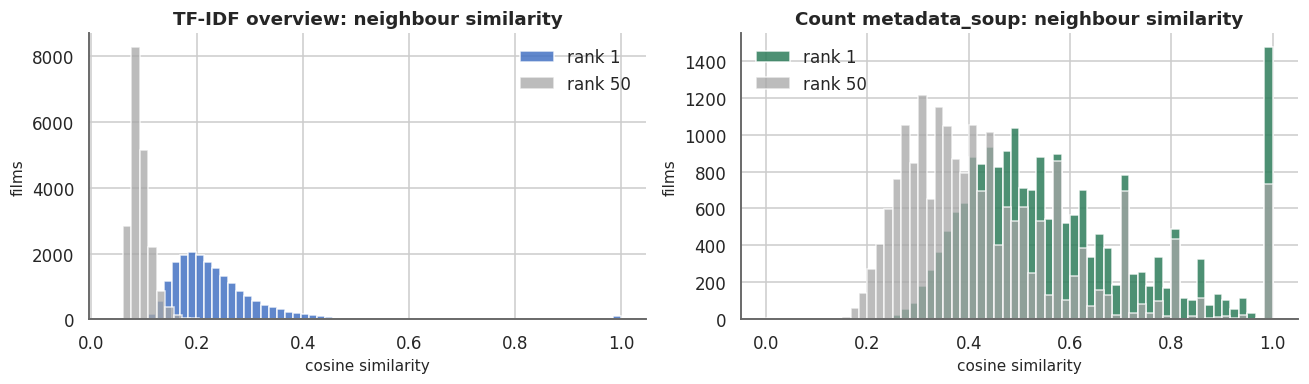

plot      rank-1 similarity: median 0.217, 130 films have a near-duplicate (>0.9)
metadata  rank-1 similarity: median 0.544, 1,795 films have a near-duplicate (>0.9)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, table, label, colour in [
    (axes[0], neighbours_plot, "TF-IDF overview", ACCENT),
    (axes[1], neighbours_meta, "Count metadata_soup", POS),
]:
    top1 = table.filter(pl.col("rank") == 1)["similarity"].to_numpy()
    top50 = table.filter(pl.col("rank") == 50)["similarity"].to_numpy()
    ax.hist(top1, bins=60, color=colour, alpha=.85, label="rank 1")
    ax.hist(top50, bins=60, color=MUTED, alpha=.75, label=f"rank {TOP_N}")
    ax.set_title(f"{label}: neighbour similarity")
    ax.set_xlabel("cosine similarity"); ax.set_ylabel("films")
    ax.legend(frameon=False)
sns.despine()
save_fig(fig, "fe_neighbour_similarity")
plt.show()

for table, label in [(neighbours_plot, "plot"), (neighbours_meta, "metadata")]:
    t1 = table.filter(pl.col("rank") == 1)["similarity"]
    print(f"{label:9} rank-1 similarity: median {t1.median():.3f}, "
          f"{(t1 > 0.9).sum():,} films have a near-duplicate (>0.9)")

The rank-1 distributions say something useful about the two modules. Metadata similarity
concentrates near the top of the scale because films sharing a director and two genres look
nearly identical under a count vector, while plot similarity is more spread out. Sequels and
re-releases account for most of the near-duplicates.

## 8. Persisting the artifacts

In [16]:
def save_sparse(matrix, movie_ids, name: str) -> None:
    sp.save_npz(ARTIFACTS / f"{name}.npz", matrix.tocsr())
    np.save(ARTIFACTS / f"{name}_ids.npy", np.asarray(movie_ids, dtype=np.int32))


t = time.time()
save_sparse(X_overview, overview_ids, "tfidf_overview")
save_sparse(X_soup, soup_ids, "count_soup")
joblib.dump(tfidf, ARTIFACTS / "tfidf_overview_vectorizer.joblib", compress=3)
joblib.dump(counter, ARTIFACTS / "count_soup_vectorizer.joblib", compress=3)
joblib.dump(scaler, ARTIFACTS / "structured_scaler.joblib", compress=3)

(pl.from_pandas(structured_features.reset_index(names="movie_id"))
   .write_parquet(ARTIFACTS / "structured_features.parquet", compression="snappy"))
neighbours_plot.write_parquet(ARTIFACTS / "neighbours_tfidf_overview.parquet")
neighbours_meta.write_parquet(ARTIFACTS / "neighbours_count_soup.parquet")

manifest = {
    "generated_at_utc": pd.Timestamp.utcnow().isoformat(),
    "source_table": "movies_merged",
    "catalogue_films": items.height,
    "random_state": RANDOM_STATE,
    "representations": {
        "tfidf_overview": {**{k: v for k, v in info_tfidf.items() if k != "representation"},
                           "params": {k: str(v) for k, v in TFIDF_PARAMS.items()}},
        "count_soup": {**{k: v for k, v in info_soup.items() if k != "representation"},
                       "params": {k: str(v) for k, v in COUNT_PARAMS.items()}},
        "structured": {"rows": int(structured_features.shape[0]),
                       "features": int(structured_features.shape[1]),
                       "numeric": NUMERIC, "log_scaled": LOG_SCALE,
                       "genre_flags": len(keep_genres)},
        "sbert": ({"model": SBERT_MODEL, "rows": int(embeddings.shape[0]),
                   "dims": int(embeddings.shape[1])} if SBERT_AVAILABLE else None),
    },
    "neighbours": {"top_n": TOP_N, "query_limit": TOPN_LIMIT,
                   "tfidf_edges": neighbours_plot.height,
                   "soup_edges": neighbours_meta.height},
    "environment": {"python": sys.version.split()[0], "polars": pl.__version__},
}
(ARTIFACTS / "feature_manifest.json").write_text(json.dumps(manifest, indent=2, default=str))

print(f"wrote artifacts in {time.time() - t:.0f}s to {ARTIFACTS.relative_to(ROOT)}\n")
display(pd.DataFrame(
    [{"file": p.name, "MB": round(p.stat().st_size / 1024**2, 2)}
     for p in sorted(ARTIFACTS.iterdir())]
))

wrote artifacts in 6s to datasets/processed/features



/tmp/ipykernel_13253/3752630511.py:19: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "generated_at_utc": pd.Timestamp.utcnow().isoformat(),


,file,MB
0,count_soup.npz,1.83
1,count_soup_ids.npy,0.34
2,count_soup_vectorizer.joblib,0.59
3,feature_manifest.json,0.00
4,neighbours_count_soup.parquet,3.21
5,neighbours_tfidf_overview.parquet,6.64
6,structured_features.parquet,2.48
7,structured_scaler.joblib,0.00
8,tfidf_overview.npz,15.66
9,tfidf_overview_ids.npy,0.33


## 9. Reload check

In [17]:
# The artifacts are only useful if they reload into something equivalent. This is also
# the cold-start path: an unseen film is vectorised by the persisted vectoriser and
# scored without retraining anything.
reloaded_vec = joblib.load(ARTIFACTS / "tfidf_overview_vectorizer.joblib")
reloaded_mat = sp.load_npz(ARTIFACTS / "tfidf_overview.npz")
reloaded_ids = np.load(ARTIFACTS / "tfidf_overview_ids.npy")

print(f"matrix identical : {(reloaded_mat != X_overview).nnz == 0}")
print(f"ids identical    : {np.array_equal(reloaded_ids, overview_ids)}")

unseen = ("A retired thief is pulled back for one last heist in Tokyo, "
          "betrayed by the crew he trained.")
vector = reloaded_vec.transform([unseen])
cold_index = ContentIndex(reloaded_mat, reloaded_ids, items, "reloaded")
print(f"\ncold-start query: {unseen}")
display(cold_index.similar_to_vector(vector, k=8)[
    ["similarity", "title_clean", "release_year"]].round(3))

matrix identical : True
ids identical    : True



cold-start query: A retired thief is pulled back for one last heist in Tokyo, betrayed by the crew he trained.


,similarity,title_clean,release_year
movie_id,,,
221162,0.186,Naked Singularity,2021.0
117140,0.183,Columbus Day,2008.0
100108,0.176,Parker,2013.0
129323,0.173,Killer's Gold,1979.0
157432,0.173,Precious Cargo,2016.0
267804,0.172,Miss Dundee and Her Performing Dogs,1902.0
230345,0.166,The Day of the Lord,2020.0
1472,0.163,City of Industry,1997.0


---
## Summary

Artifacts under `datasets/processed/features/`:

| File | Contents |
|---|---|
| `tfidf_overview.npz` + `_ids.npy` | Sparse TF-IDF matrix and its row-to-`movie_id` map |
| `count_soup.npz` + `_ids.npy` | Sparse count matrix over `metadata_soup` |
| `*_vectorizer.joblib` | Fitted vectorisers, needed to encode unseen films |
| `structured_features.parquet` | Scaled numerics, missingness indicators, multi-hot genres |
| `structured_scaler.joblib` | Fitted `StandardScaler` |
| `neighbours_*.parquet` | Top-50 neighbour tables |
| `feature_manifest.json` | Parameters, shapes and densities for every representation |

Three points to carry into modelling.

Each representation covers a different population, so a row index is only meaningful alongside
its own `_ids.npy`. Comparing the plot and metadata modules on ranking metrics without first
restricting to their intersection measures coverage, not representation quality.

Budget and revenue needed the zero-to-NaN correction before scaling. Any later feature work
touching the raw columns has to repeat it.

The reload check at the end doubles as the cold-start mechanism: an unseen synopsis is
vectorised with the persisted vectoriser and scored against the catalogue without retraining,
which is the design the proposal argues for.